**El primer paso es realizar un análisis exploratorio, es importante conocer nuestros datos para saber qué podemos hacer con ellos.**

En primer lugar, hay que cargar los datos al entorno de colab para poder cargarlos depués. Las siguientes líneas muestran un botón para abrir un explorador y cargar los datos, aunque es posible realizar esto desde la interfaz de usuario a través del ícono de carpeta.
Esto no es necesario cuando trabajas con IDE locales, solo debes conocer bien la ruta a tus datos o, mejor aún, tenerlos en el mismo directorio.

In [113]:
from google.colab import files
uploaded = files.upload()

Saving full.csv to full (2).csv


Las siguientes líneas cargan la librería que se utilizará, para posteriormente indicarle a python que lea nuestros datos para que trabajemos con ellos. Por eso es importante conocer el tipo y estructura de los datos
El archivo es csv, por eso se utiiza pd.read_csv.
Primero está el nombre del archivo (aunque, si no está en el mismo directorio, será necesario especificar la ruta hacia él).
En segundo lugar, se le indica a python que ignore las líneas que inician con # (ya que los datos tienen un encabezado cuyas líneas comienzan así) de lo contrario, obtendremos un error.
Cada pieza de información está separada por comas, pero encerrada entre comillas, esto se indica en el tercer argumento.
Por último, se indica que si algo comienza con un espacio, este espacio se ignore y prosiga.
Todo lo anterior se escribió a partir de conocer los datos y al solucionar errores que surgían al ejecutar.

In [114]:
import pandas as pd
datos = pd.read_csv("full.csv", comment='#', quotechar='"', skipinitialspace=True)

A continuación, se observan las primeras filas de las columnas (con .head()) y se detecta el tipo de cada una (con .dtypes). Luego, con .describe(), aparece un resumen estadístico de los datos. En este caso se trabaja con variables cualitativas, por lo que añade el argumento include = "all" para que se presente información sobre este tipo de datos.
Una opción que proporciona el tipo de dato, junto a otro tipo de información es .info()

In [115]:
print(datos.head())

        first_seen_utc   ioc_id                          ioc_value ioc_type  \
0  2026-08-17 22:24:50  1878680               faustformelsystem.ch   domain   
1  2026-08-17 22:15:44  1878677  http://kupzovo.shop:7567/accounts      url   
2  2026-08-17 21:31:04  1878666             https://bolerkas.shop/      url   
3  2026-08-17 21:31:03  1878665              https://bolerkas.sbs/      url   
4  2026-08-17 21:14:28  1878663          designtrustventures.co.ke   domain   

        threat_type    fk_malware malware_alias malware_printable  \
0  payload_delivery  js.clearfake           NaN         ClearFake   
1         botnet_cc     win.remus           NaN             Remus   
2  payload_delivery       unknown           NaN   Unknown malware   
3  payload_delivery       unknown           NaN   Unknown malware   
4  payload_delivery  js.clearfake           NaN         ClearFake   

  last_seen_utc  confidence_level  is_compromised  \
0           NaN                90           False   
1   

In [116]:
print(datos.dtypes)

first_seen_utc       object
ioc_id                int64
ioc_value            object
ioc_type             object
threat_type          object
fk_malware           object
malware_alias        object
malware_printable    object
last_seen_utc        object
confidence_level      int64
is_compromised         bool
reference            object
tags                 object
anonymous             int64
reporter             object
dtype: object


In [117]:
print(datos.describe(include = "all"))

             first_seen_utc        ioc_id                     ioc_value  \
count                102542  1.025420e+05                        102542   
unique                69657           NaN                        101613   
top     2026-07-29 04:32:13           NaN  api-ext.bixbitemarketing.com   
freq                     36           NaN                             3   
mean                    NaN  1.781151e+06                           NaN   
std                     NaN  1.580664e+05                           NaN   
min                     NaN  5.300000e+01                           NaN   
25%                     NaN  1.769762e+06                           NaN   
50%                     NaN  1.805934e+06                           NaN   
75%                     NaN  1.850009e+06                           NaN   
max                     NaN  1.878680e+06                           NaN   

       ioc_type threat_type    fk_malware  \
count    102542      102542        102542   
unique   

In [118]:
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102542 entries, 0 to 102541
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   first_seen_utc     102542 non-null  object
 1   ioc_id             102542 non-null  int64 
 2   ioc_value          102542 non-null  object
 3   ioc_type           102542 non-null  object
 4   threat_type        102542 non-null  object
 5   fk_malware         102542 non-null  object
 6   malware_alias      24661 non-null   object
 7   malware_printable  102542 non-null  object
 8   last_seen_utc      46332 non-null   object
 9   confidence_level   102542 non-null  int64 
 10  is_compromised     102542 non-null  bool  
 11  reference          28010 non-null   object
 12  tags               92188 non-null   object
 13  anonymous          102542 non-null  int64 
 14  reporter           102542 non-null  object
dtypes: bool(1), int64(3), object(11)
memory usage: 11.1+ MB
None


La columna confidence level nos dice qué tan probable es que un IOC sea una amenaza. No nos interesan demasiado aquellas sin una probabilidad real, así que, revisando el mínimo, existen datos con un 0 de confianza.
Solo nos interesarán aquellos quetengan más de la mitad de probabilidades de ser una amenaza

In [119]:
print(datos['confidence_level'].min())

0


In [120]:
datos = datos[datos['confidence_level']>50]

In [121]:
print(datos.describe(include="all"))

             first_seen_utc        ioc_id                     ioc_value  \
count                 95355  9.535500e+04                         95355   
unique                66759           NaN                         94509   
top     2026-03-03 23:00:21           NaN  api-ext.bixbitemarketing.com   
freq                     29           NaN                             3   
mean                    NaN  1.782507e+06                           NaN   
std                     NaN  1.592274e+05                           NaN   
min                     NaN  5.300000e+01                           NaN   
25%                     NaN  1.771046e+06                           NaN   
50%                     NaN  1.806753e+06                           NaN   
75%                     NaN  1.850316e+06                           NaN   
max                     NaN  1.878680e+06                           NaN   

       ioc_type       threat_type    fk_malware  \
count     95355             95355         95355 

Fue posible detectar que dos de las columnas eran fechas, así que se convierten a dicho formato.
Hay que destacar que previamente se conocieros los nombres de las columnas. Al escribir nombre_conjunto["columna"], se indica que el código se va a ejecutar solo sobre dicha columna. Aquí le estamos diciendo, cambia la columna "first_seen_utc" del conjunto datos por la conversión a fecha de la columna "first_seen_utc" del conjunto datos, e ignora los errores.

In [122]:
datos["first_seen_utc"] = pd.to_datetime(datos['first_seen_utc'], errors='coerce')
datos["last_seen_utc"] = pd.to_datetime(datos['last_seen_utc'], errors='coerce')

Si imprimimos el tipo de datos, el tipo para estas columnas cambió a datetime

In [123]:
print(datos.dtypes)

first_seen_utc       datetime64[ns]
ioc_id                        int64
ioc_value                    object
ioc_type                     object
threat_type                  object
fk_malware                   object
malware_alias                object
malware_printable            object
last_seen_utc        datetime64[ns]
confidence_level              int64
is_compromised                 bool
reference                    object
tags                         object
anonymous                     int64
reporter                     object
dtype: object


Para conocer un poco más de los datos y entender las columnas, observamos cuáles son nuestra primera y última fechas. Destaca el hecho de que los primeros registros datan de 2020. La fecha en que fue observado por primera vez un IOC se mantiene. Si quisiéramos hacer una serie de tiempo con las amenazas registradas en los últimos 6 meses, nos interesa la columna last_seen_utc

In [124]:
print("La fecha más antigua registrada es:", datos["first_seen_utc"].min())
print("La fecha más reciente registrada es:", datos["first_seen_utc"].max())

La fecha más antigua registrada es: 2020-12-14 08:44:34
La fecha más reciente registrada es: 2026-08-17 22:24:50


Además, es necesario identificar los datos nulos (ausentes), para saber qué se puede hacer con ellos. Hay muchos nulos en last_seen_utc.

In [125]:
datos.isnull().sum()

,0
first_seen_utc,0
ioc_id,0
ioc_value,0
ioc_type,0
threat_type,0
fk_malware,0
malware_alias,72952
malware_printable,0
last_seen_utc,51344
confidence_level,0


Apartir de nuestro análisis principal, sabemos que estos nulos se deben a que, si la fecha de primera vez observados es la única vez, no se agrega a last_seen_utc. Esto se soluciona fácilmente rellenando los nulos en last_seen_utc con la información de first_seen_utc.
Se está creando una nueva columna y, aunque la estructura es igual a reasignar columnas existentes, la diferencia es, precisamente, que no existían y se crearán de cero. Usamos el formato conjunto["nueva_columna] = ...

In [126]:
datos["secuencia"] = datos["last_seen_utc"].fillna(datos["first_seen_utc"])

A partir de ello podemos extraer datos como la fecha, el día de la semana y la hora de la amenaza.

In [127]:
datos["dia"] = (datos["secuencia"]).dt.date
datos["dia_week"] = (datos["secuencia"]).dt.day_of_week
datos["hora"] = (datos["secuencia"]).dt.hour

Para poder empezar a generar gráficos con los datos, es necesario agruparlos, para que solo utilicemos la clase y el número de ocurrencias. Utilizamos .value_counts() para que precisamente realice esta suma.

In [128]:
agrupados = datos['threat_type'].value_counts().reset_index()
agrupados.columns = ['threat_type', 'cantidad_detectada']

Para graficar se importa la librería matplotlib.
Un gráfico de barras básico se genera con el comando plt.bar(datos_ejex, datos_ejey).En este caso se utilizan las columnas del tipo de amenaza y el conteo. Es posible agregar elementos al gráfico, para ello, consultar la documentación de matplotlib.

/tmp/ipykernel_5474/2605997826.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(agrupados["threat_type"],rotation=45, ha='right')


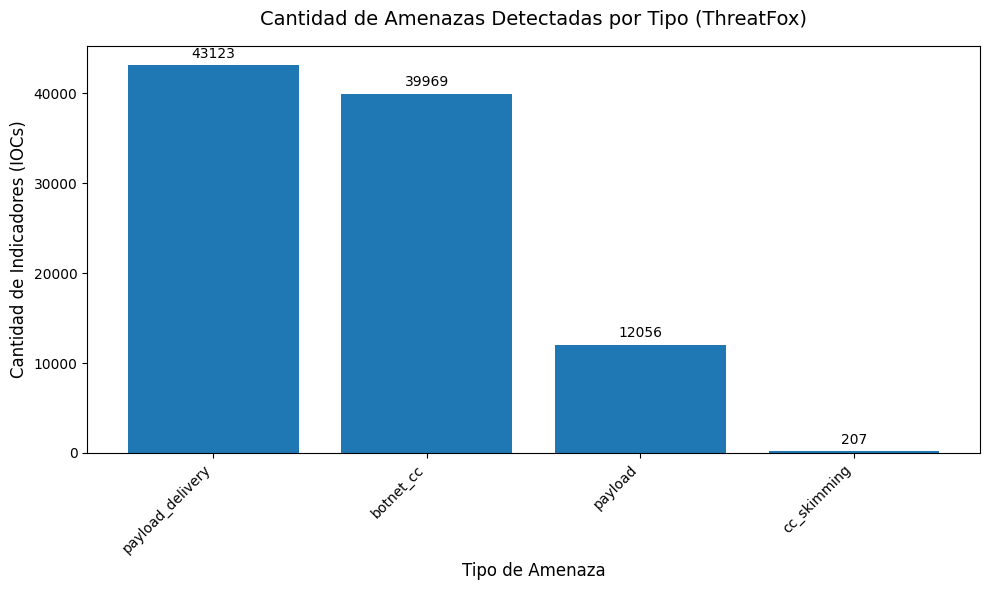

In [129]:
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(figsize=(10, 6))
barras = ax1.bar(agrupados["threat_type"], agrupados["cantidad_detectada"])

ax1.set_title("Cantidad de Amenazas Detectadas por Tipo (ThreatFox)", fontsize=14, pad=15)
ax1.set_xlabel("Tipo de Amenaza", fontsize=12)
ax1.set_ylabel("Cantidad de Indicadores (IOCs)", fontsize=12)
ax1.set_xticklabels(agrupados["threat_type"],rotation=45, ha='right')
ax1.bar_label(barras, padding=3, fontsize=10, color='black')
fig1.tight_layout()

fig1.savefig("grafico_barras.png", bbox_inches = 'tight', transparent = True)

También se puede realizar un gráfico de barras, cuando queremos saber qué porcentaje de un total representa cada categoría. Es importante evitar incluir demasiadas categorías, pues se podría obtener un gráfico difícil de interpretar.
La sintaxis es plt.pie(x = datos_para_porcentajes, labels = etiquetas)

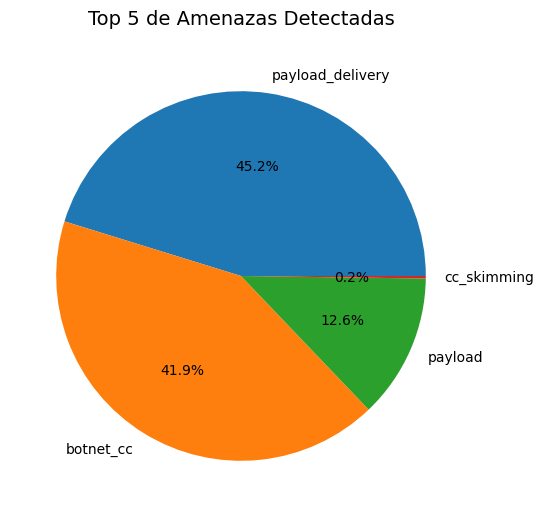

In [130]:
fig2,ax2 = plt.subplots(figsize=(10, 6))
ax2.pie(x=agrupados['cantidad_detectada'], labels=agrupados["threat_type"], autopct='%1.1f%%')
ax2.set_title("Top 5 de Amenazas Detectadas", fontsize=14, pad=15)
fig2.savefig("grafico_pastel.png", bbox_inches='tight', transparent=True)

Después se ordenan los datos por fecha para realmente tener una serie de tiempo que se pueda graficar y analizar.

In [131]:
totales_dia = datos.groupby("dia").size().reset_index(name="count")
print(totales_dia)

            dia  count
0    2026-02-17    723
1    2026-02-18    523
2    2026-02-19    358
3    2026-02-20    415
4    2026-02-21    657
..          ...    ...
177  2026-08-13    560
178  2026-08-14   2357
179  2026-08-15   1002
180  2026-08-16    563
181  2026-08-17   4112

[182 rows x 2 columns]


Incluso imprimiendo los datos ordenados de mayor a menor podemos obtener información valiosa, como el día con mayores registros.

In [132]:
print(totales_dia.head())

          dia  count
0  2026-02-17    723
1  2026-02-18    523
2  2026-02-19    358
3  2026-02-20    415
4  2026-02-21    657


También se pueden generar gráficos de líneas que permiten detectar la evolución de una variable (el número de amenazas) en el tiempo, para eso se usa pl.plot(datos_ejex, datos_ejey)

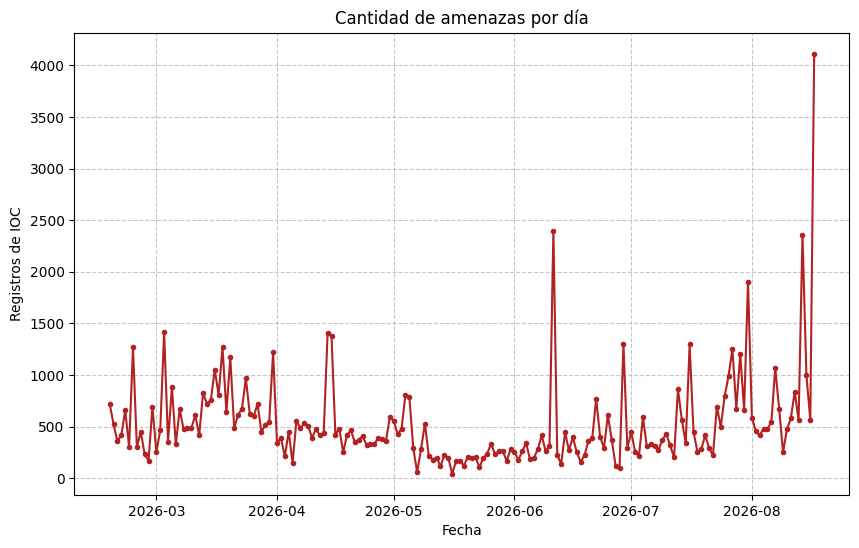

In [133]:
fig3,ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(totales_dia["dia"], totales_dia['count'], marker='.', color='firebrick')
ax3.set_title("Cantidad de amenazas por día")
ax3.set_xlabel("Fecha")
ax3.set_ylabel("Registros de IOC")
ax3.grid(True, linestyle='--', alpha=0.7)

fig3.savefig("grafico_lineas.png", bbox_inches = 'tight', transparent = True)

Solo porque estamos en colab tenemos que descargar los archivos a nuestra computadora, esto mediante files.download()

Sabemos que hay algunas columnas que incluyen la clase de cada dato dentro de una clasificación definida. Este es un tipo de dato especial, y transformándolo a category, podemos hacer operaciones adicionales y ahorrar espacio

In [134]:
cols = ["ioc_type", "threat_type"]
datos[cols] = datos[cols].astype('category')
print(datos.describe(include=['category']))

       ioc_type       threat_type
count     95355             95355
unique        6                 4
top      domain  payload_delivery
freq      49204             43123


Hay un pequeño problema, es posible que existan días u horas sin ocurrencias, y si vamos a realizar un análisis, hay que tomar esto en cuenta.  
El primer paso es establecer la información temporal como índice.  
Se puede ustilizar group by para agrupar los datos por hora o día de la semana, pero en este caso se usa resample, que incluirá las fechas u horas vacías y establecerá el total en 0.

In [135]:
datos = datos.set_index('secuencia')

También se puede elaborar un pequeño resumen estadístico

In [136]:
# Al usar resample, 'D' significa que cuente por Día (Daily)
# Si no hubo ataques en un día, Pandas automáticamente pone un 0.
ataques_diarios = datos.resample('D').size().reset_index(name='total_ataques')

# Como resample() borró nuestras otras columnas, volvemos a extraer el día de la semana
ataques_diarios['dia_week'] = ataques_diarios['secuencia'].dt.day_of_week

# Imprimimos para verificar que ya no hay saltos en el calendario
print("Ataques diarios:")
print(ataques_diarios.head(15))

Ataques diarios:
    secuencia  total_ataques  dia_week
0  2026-02-17            723         1
1  2026-02-18            523         2
2  2026-02-19            358         3
3  2026-02-20            415         4
4  2026-02-21            657         5
5  2026-02-22            304         6
6  2026-02-23           1267         0
7  2026-02-24            300         1
8  2026-02-25            449         2
9  2026-02-26            231         3
10 2026-02-27            171         4
11 2026-02-28            690         5
12 2026-03-01            252         6
13 2026-03-02            464         0
14 2026-03-03           1413         1


In [137]:
# Usamos .agg() para pedir múltiples estadísticas matemáticas al mismo tiempo
estadisticas_semana = ataques_diarios.groupby('dia_week')['total_ataques'].agg(['sum','mean', 'std', 'min', 'max']).reset_index()

# Asignar los nombres de los días
dias_nombres = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
estadisticas_semana['dia_week'] = estadisticas_semana['dia_week'].map(lambda x: dias_nombres[x])

# Asignar los nombres de las columnas
estadisticas_semana.columns = ['Día de la Semana', 'Total', 'Promedio', 'Desviación Estándar', 'Mínimo', 'Máximo']

print("Resumen estadístico por día de la semana:")
print(estadisticas_semana)

Resumen estadístico por día de la semana:
  Día de la Semana  Total    Promedio  Desviación Estándar  Mínimo  Máximo
0            Lunes  18599  715.346154           768.045881     166    4112
1           Martes  14393  553.576923           358.904240     122    1413
2        Miércoles  12556  482.923077           333.385893     115    1377
3           Jueves  14070  541.153846           457.195686      58    2398
4          Viernes  14446  555.615385           535.816542     171    2357
5           Sábado  11476  441.384615           244.373170      43    1002
6          Domingo   9815  377.500000           200.200549      95     990


Otra librería ampliamente utilizada para graficar datos es seaborn. Proporciona funciones adicionales a matplotlib (aunque está basada en esta, y matplotlib no deja de ser fundamental en Python).  
Puede utilizarse para construir un gráfico común en análists estadísticos: de caja y bigote, que nos brinda información sobre máximo y mínimo, media, desviación estándar y número de ocurrencias.

/tmp/ipykernel_5474/474257524.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


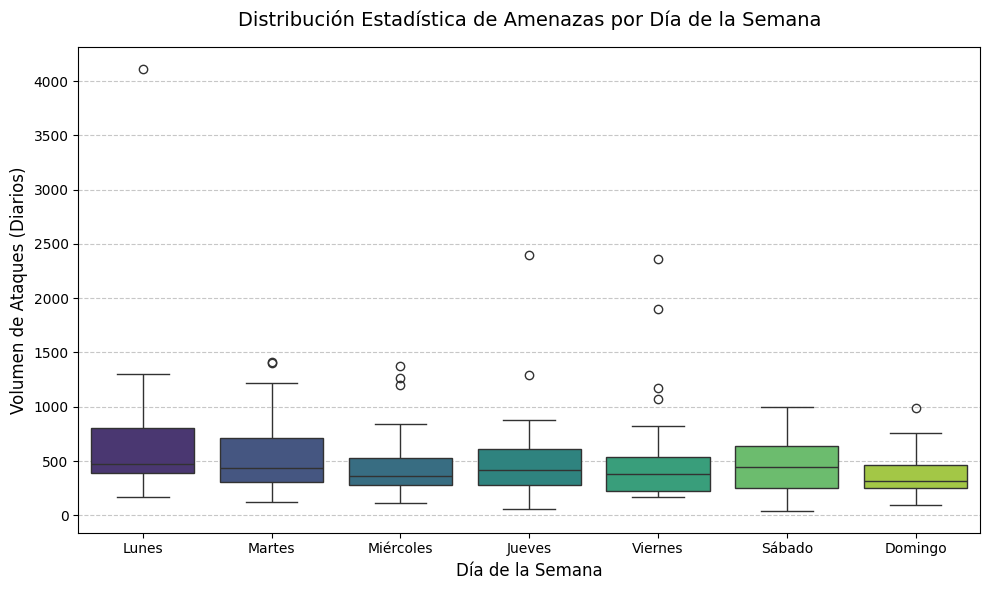

In [138]:
import seaborn as sns

# Acomodar los datos
dias_nombres = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
ataques_diarios['nombre_dia'] = ataques_diarios['dia_week'].map(lambda x: dias_nombres[x])

fig4, ax4 = plt.subplots(figsize=(10, 6))

# Crear el gráfico de caja con Seaborn
# El parámetro 'order' garantiza que los días salgan de Lunes a Domingo y no desordenados
# 'palette' asigna unapaleta específica
sns.boxplot(
    data=ataques_diarios,
    x='nombre_dia',
    y='total_ataques',
    order=dias_nombres,
    palette='viridis',
    ax=ax4
)

# Títulos y etiquetas
ax4.set_title("Distribución Estadística de Amenazas por Día de la Semana", fontsize=14, pad=15)
ax4.set_xlabel("Día de la Semana", fontsize=12)
ax4.set_ylabel("Volumen de Ataques (Diarios)", fontsize=12)

# Cuadrícula solo en el eje Y para facilitar la lectura
ax4.yaxis.grid(True, linestyle='--', alpha=0.7)
ax4.xaxis.grid(False)

fig4.tight_layout()
fig4.savefig("grafico_cajas.png", bbox_inches='tight', transparent=True)
#plt.show()

Es notorio que no hay mucha diferencia entre el número de ataques y el día de la semana (aunque el domingo presenta menos ocurrencias y el lunes más).   También se puede detectar la presencia de anomalías (aunque no señalar la instancia específica que la presenta).

In [139]:
# Resampleamos por 'h' (Hora). Creará un registro para cada hora, cada día de los 6 meses.
ataques_hora = datos.resample('h').size().reset_index(name='total_ataques')

# Extraemos la hora del día (del 0 al 23) para poder agruparla y graficar
ataques_hora['hora'] = ataques_hora['secuencia'].dt.hour

# Usamos .agg() para pedir múltiples estadísticas matemáticas al mismo tiempo
estadisticas_hora = ataques_hora.groupby('hora')['total_ataques'].agg(['sum','mean', 'std', 'min', 'max']).reset_index()

# Asignar los nombres de las columnas
estadisticas_hora.columns = ['Hora', 'Total', 'Promedio', 'Desviación Estándar', 'Mínimo', 'Máximo']

print("Resumen estadístico por hora:")
print(estadisticas_hora)

Resumen estadístico por hora:
    Hora  Total   Promedio  Desviación Estándar  Mínimo  Máximo
0      0   2184  12.066298            20.992751       0     194
1      1   2685  14.752747            36.206427       0     253
2      2   1434   7.879121            17.723372       0     226
3      3   1483   8.148352             9.364620       0      65
4      4   2123  11.664835            29.473329       0     369
5      5   3328  18.285714            29.634527       0     256
6      6   4471  24.565934            26.496399       0     160
7      7   8499  46.697802           138.957332       0    1311
8      8   6476  35.582418            79.648547       0     652
9      9   3125  17.170330            20.567329       0     167
10    10   4811  26.434066           163.507661       0    2213
11    11   3530  19.395604            29.083944       0     256
12    12   5648  31.032967            81.104932       0     827
13    13   3602  19.791209            52.399341       0     654
14    14  

In [140]:
print(ataques_diarios)

     secuencia  total_ataques  dia_week nombre_dia
0   2026-02-17            723         1     Martes
1   2026-02-18            523         2  Miércoles
2   2026-02-19            358         3     Jueves
3   2026-02-20            415         4    Viernes
4   2026-02-21            657         5     Sábado
..         ...            ...       ...        ...
177 2026-08-13            560         3     Jueves
178 2026-08-14           2357         4    Viernes
179 2026-08-15           1002         5     Sábado
180 2026-08-16            563         6    Domingo
181 2026-08-17           4112         0      Lunes

[182 rows x 4 columns]


/tmp/ipykernel_5474/1656931373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


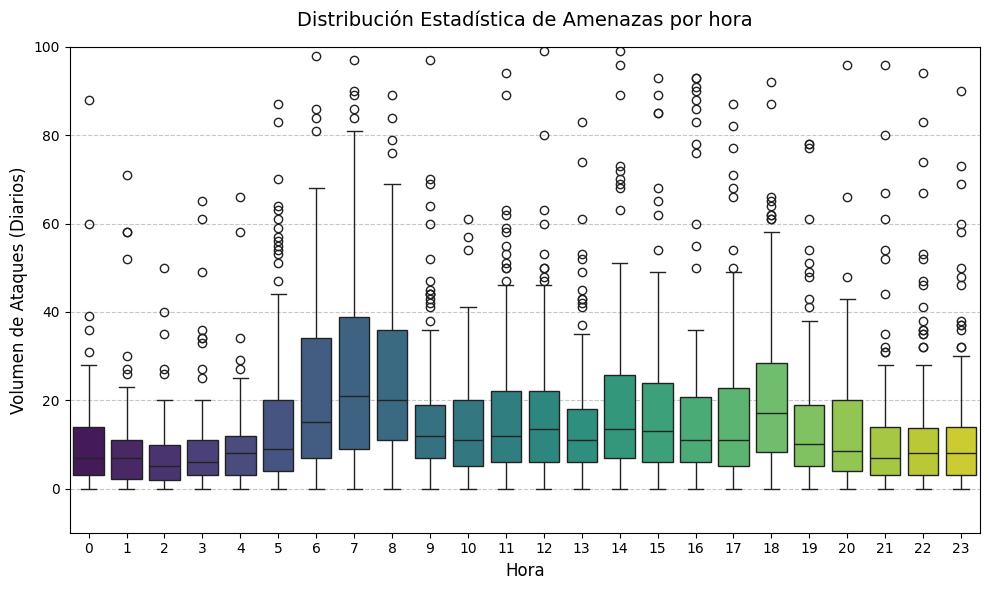

In [141]:
fig5, ax5 = plt.subplots(figsize=(10, 6))

# Crear el gráfico de caja con Seaborn
# El parámetro 'order' garantiza que los días salgan de Lunes a Domingo y no desordenados
# 'palette' asigna una paleta específica
sns.boxplot(
    data=ataques_hora,
    x='hora',
    y='total_ataques',
    palette='viridis',
    ax=ax5
)

# Títulos y etiquetas
ax5.set_title("Distribución Estadística de Amenazas por hora", fontsize=14, pad=15)
ax5.set_xlabel("Hora", fontsize=12)
ax5.set_ylabel("Volumen de Ataques (Diarios)", fontsize=12)
ax5.set_ylim(top=100, bottom=-10)

# Cuadrícula solo en el eje Y para facilitar la lectura
ax5.yaxis.grid(True, linestyle='--', alpha=0.7)
ax5.xaxis.grid(False)

fig5.tight_layout()
fig5.savefig("grafico_cajas_hora.png", bbox_inches='tight', transparent=True)
#plt.show()

Si quisiéramos graficar la familia de malware, tendríamos que considerer un número adecuado de clases, para evitar gráficos difíciles de entender.

In [155]:
# Obtenemos el nombre exacto de las 20 familias más frecuentes
top_20_familias = datos['fk_malware'].value_counts().head(20).index

# Pasar lacolumna a texto (string) temporalmente para poder agregar la nueva palabra "Otros" sin que marque error.
datos['fk_malware_limpio'] = datos['fk_malware'].astype(str)

# Conservar si está en el top 20, cambiar a "Otros" si no.
datos['fk_malware_limpio'] = datos['fk_malware_limpio'].where(
    datos['fk_malware_limpio'].isin(top_20_familias),
    'Otros'
)

In [148]:
pip install lets-plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.7 MB/s eta 0:00:00


Otra librería para graficar es Lets Plot, es menos popular debido a que su sintaxis es más parecida a la de R (ggplot) que a la de Python. Aún así, vale la pena repasarla, considerando la calidad de sus gráficos. Para más información, consultar su documentación online

In [169]:
from lets_plot import *

# Inicializamos lets-plot (necesario para que se vea en el entorno de Python)
LetsPlot.setup_html()

# Creamos el gráfico base
# En lets-plot, geom_bar por defecto utiliza stat='count' y position='stack', por lo que apilará los colores automáticamente
grafico = (
    # CORRECCIÓN AQUÍ: Se usa order=-1 para descendente y se elimina el order_by suelto
    ggplot(datos, aes(
        x=as_discrete('fk_malware_limpio', order_by='..count..', order=-1),
        fill='ioc_type'
    )) +
    geom_bar(color="black", size=0.2) +
    # Ajustes estéticos
    labs(
        title="Top 20 Familias de Malware por Tipo de IOC entre Febreo y Agosto del 2026",
        x="Familia de Malware",
        y="Cantidad de Registros",
        fill="Tipo de Amenaza" # Título de la leyenda
    ) +

    # Rotar el texto del eje X a 90 grados para que los nombres del malware se puedan leer
    theme(
        axis_text_x=element_text(angle=90, hjust=1),
        # Para hacer un gráfico transparente
        # Hacemos transparente el fondo general de la imagen
        plot_background=element_rect(fill='transparent', color='transparent'),

        # Hacemos transparente el panel interno (detrás de las barras)
        panel_background=element_rect(fill='transparent', color='transparent')
          )
)


#Guardar imagen
ggsave(grafico, "malware_apilado.png", path=".",w=10, h=6, unit='in', dpi=300)

'/content/malware_apilado.png'

In [167]:
files.download("grafico_barras.png")
files.download("grafico_lineas.png")
files.download("grafico_pastel.png")
files.download("grafico_cajas.png")
files.download("grafico_cajas_horas.png")
files.download("malware_apilado.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Donde se observa un ligero aumento hacia la 7 de la mañana

Se puede elaborar un reporte de texto automático.

In [143]:
informe1 = f"El día en que ocurrieron más ataques fue el: {totales_dia.loc[totales_dia['count'].idxmax()]['dia']}\nEl día de la semana en que hay más IOC en promedio es el {estadisticas_semana.loc[estadisticas_semana['Promedio'].idxmax()]['Día de la Semana']}. \nLa hora del día en que se detectaron más IOC fue a las {estadisticas_hora.loc[estadisticas_hora['Promedio'].idxmax()]['Hora']} horas"
print(informe1)

El día en que ocurrieron más ataques fue el: 2026-08-17
El día de la semana en que hay más IOC en promedio es el Lunes. 
La hora del día en que se detectaron más IOC fue a las 7.0 horas


In [144]:
datos['mes'] = datos.index.month_name()

columnas_interes = ["ioc_type", "fk_malware", "threat_type", "dia", "hora","dia_week", "mes"]

# Generamos el describe() solo para esas columnas y extraemos la fila 'top'
# (Usamos .astype('category') por si el mes se creó como texto normal)

los_mas_frecuentes = datos[columnas_interes].astype('category').describe().loc['top']


print("Los elementos con mayor ocurrencia en el periodo son:")
print(los_mas_frecuentes)

Los elementos con mayor ocurrencia en el periodo son:
ioc_type                 domain
fk_malware         js.clearfake
threat_type    payload_delivery
dia                  2026-08-17
hora                          7
dia_week                      0
mes                       March
Name: top, dtype: object


In [145]:
texto_reporte = f"""
### Resumen de Amenazas
Durante el periodo analizado, el mes que registró mayor actividad maliciosa fue **{los_mas_frecuentes['mes']}**.
La técnica de entrega o tipo de amenaza preferida por los cibercriminales fue **{los_mas_frecuentes['threat_type']}**, distribuyendo principalmente la familia de malware **{los_mas_frecuentes['fk_malware']}**.
El tipo de infraestructura (IOC) más detectado fue **{los_mas_frecuentes['ioc_type']}**.
"""



### Resumen de Amenazas
Durante el periodo analizado, el mes que registró mayor actividad maliciosa fue **March**. 
La técnica de entrega o tipo de amenaza preferida por los cibercriminales fue **payload_delivery**, distribuyendo principalmente la familia de malware **js.clearfake**. 
El tipo de infraestructura (IOC) más detectado fue **domain**.



In [174]:
titulo = f"Análisis de IOC entre {datos["last_seen_utc"].min()} y {datos["last_seen_utc"].max()}"
print(titulo)

Análisis de IOC entre 2026-02-17 01:17:32 y 2026-08-17 22:42:27


In [170]:
warning = """Métricas como el día o la hora con más ocurrencias pueden resultar útiles, pero
las medidas estadísticas siempre deben ser interpretadas de forma cuidadosa y tomando en
cuenta partes del contexto, como medidas de tendencia central y dispersión. \n
Además, cada conjunto posee sus propias características, y debe establecerse un flujo de
trabajo particular para cada uno de ellos
"""

In [175]:
from datetime import date
fecha_hoy = date.today().strftime("%Y-%m-%d")
total_iocs = len(datos)

# Usamos f-strings para inyectar las variables directamente en el texto
plantilla_markdown = f"""# Reporte de Inteligencia de Amenazas (ThreatFox)
**Fecha de generación automática:** {fecha_hoy}

## Resumen
Durante el periodo analizado, se procesaron un total de **{total_iocs:,}** indicadores de compromiso (IOCs).
El análisis revela que el mes con mayor actividad maliciosa fue **{los_mas_frecuentes['mes']}**.

La táctica preferida por los adversarios (Threat Type) fue **{los_mas_frecuentes['threat_type']}**, utilizada principalmente para distribuir la familia de malware **{los_mas_frecuentes['fk_malware']}**. La infraestructura base más utilizada para estos ataques (IOC Type) fue **{los_mas_frecuentes['ioc_type']}**.

---

## Análisis Temporal de Actividad
A continuación, se presenta la evolución histórica de las amenazas. El gráfico de cajas y bigotes permite identificar si los atacantes tienen un patrón de trabajo centrado en días laborales o fines de semana, o alguno relacionado con las horas, así como los picos atípicos (outliers) de campañas masivas.

<p align="center">
  <img src="grafico_lineas.png" width="800">
</p>

<p align="center">
  <img src="grafico_cajas.png" width="800">
</p>

<p align="center">
  <img src="grafico_cajas_horas.png" width="800">
</p>

---

## Familias de Malware, IOC y tipo de amenaza

En primer lugar, es importante detectar el tipo de amenaza más frecuente, para identificar algunas medidas de seguridad necesarias.
<p align="center">
  <img src="grafico_barras.png" width="900">
</p>

El siguiente gráfico desglosa las familias de malware predominantes y el tipo de infraestructura que las sostiene. Las familias fuera del top 20 han sido agrupadas en la categoría "Otros" para limpiar el ruido estadístico.
<p align="center">
  <img src="malware_apilado.png" width="900">
</p>

> *Reporte generado automáticamente mediante Python y Pandas. Datos extraídos de abuse.ch (ThreatFox).*
abuse.ch, & Spamhaus. (2026). ThreatFox. Recuperado el {datos["last_seen_utc"].max()}, de https://threatfox.abuse.ch/

"""

# Guardar el texto en el archivo .md
with open("reporte_amenazas.md", "w", encoding="utf-8") as archivo:
    archivo.write(plantilla_markdown)